In [40]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle

In [41]:
print("Loading California Housing dataset...")
california = fetch_california_housing(as_frame=True)
df = california.frame

Loading California Housing dataset...


Exploratory Data Analysis (EDA)

In [42]:
print(f"Dataset Shape: {df.shape}")
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (20640, 9)

Missing Values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


correlation matrix

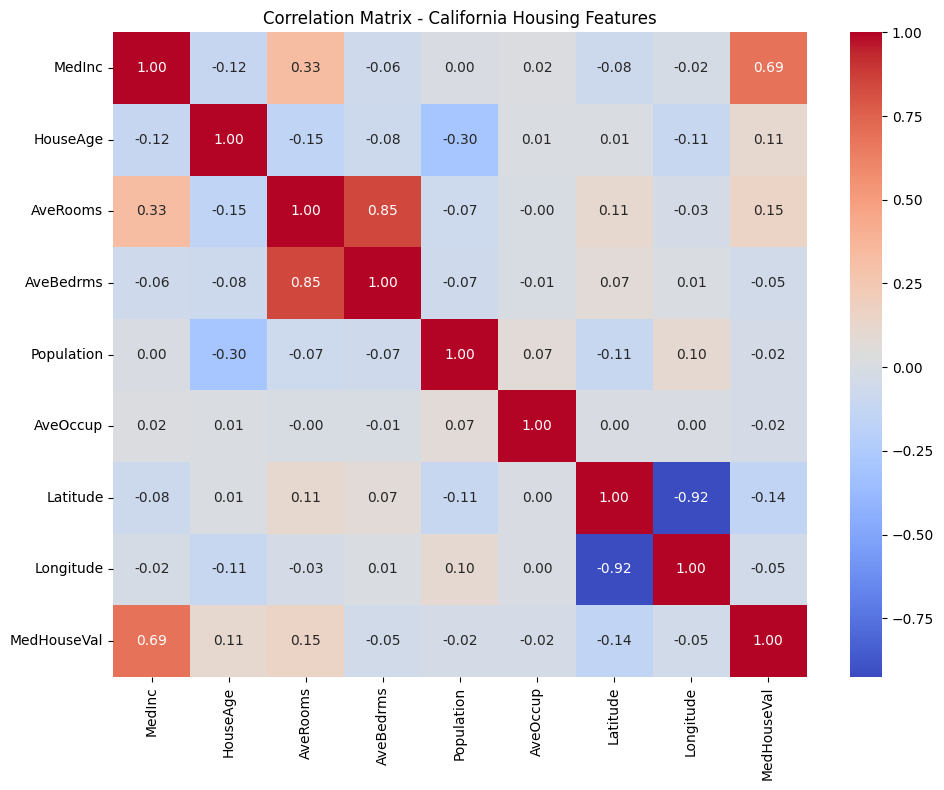

In [43]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix - California Housing Features")
plt.tight_layout()
plt.savefig("correlation_matrix.png")
plt.show()

In [44]:
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

Feature Selection & Train-Test Split
Target variable is 'MedHouseVal' (Median House Value in $100,000s)

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 14448
Testing set size: 6192


Train Linear Regression Model

In [46]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Step 5: Model Evaluation

In [47]:
y_pred = model.predict(X_test)



In [48]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)


In [49]:

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared Score (R²): {r2:.4f}")


Mean Absolute Error (MAE): 0.5272
Root Mean Squared Error (RMSE): 0.7284
R-squared Score (R²): 0.5958


Step 6: Plot Predicted vs Actual & Residuals

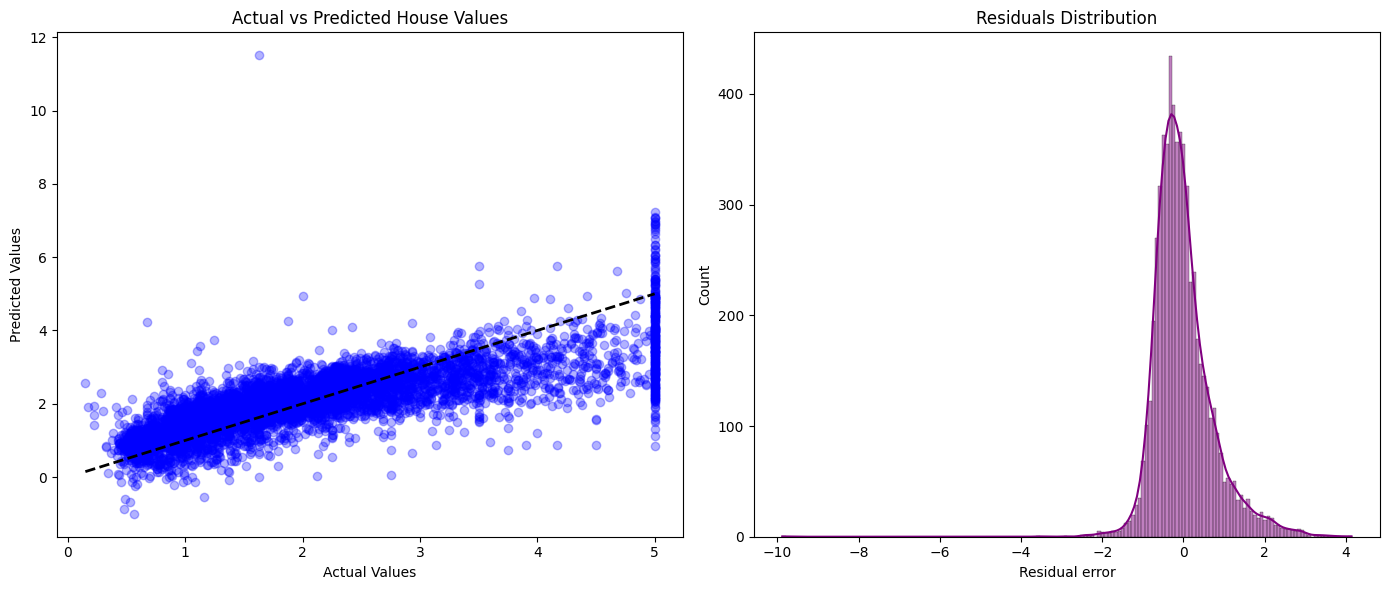


Plots saved as 'correlation_matrix.png' and 'model_performance_plots.png'.


In [50]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Actual vs Predicted
ax1.scatter(y_test, y_pred, alpha=0.3, color="blue")
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=2)
ax1.set_xlabel("Actual Values")
ax1.set_ylabel("Predicted Values")
ax1.set_title("Actual vs Predicted House Values")

# Residual Plot
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, ax=ax2, color="purple")
ax2.set_xlabel("Residual error")
ax2.set_title("Residuals Distribution")

plt.tight_layout()
plt.show()
print("\nPlots saved as 'correlation_matrix.png' and 'model_performance_plots.png'.")

Step 7: Save Model Pickle

In [51]:
model_filename = "task1_linear_regression_model.pkl"
with open(model_filename, "wb") as file:
    pickle.dump(model, file)
print(f"Model successfully exported to {model_filename}")

Model successfully exported to task1_linear_regression_model.pkl


## Report: California Housing Price Prediction

This report summarizes the steps taken to build and evaluate a Linear Regression model for predicting California housing prices, along with suggestions for future improvements.

### 1. Exploratory Data Analysis (EDA) Summary

- The California Housing dataset was loaded, containing **20,640 samples** and **9 features**, including the target variable `MedHouseVal` (Median House Value).
- No missing values were found in any of the features, indicating a clean dataset for immediate use.
- A correlation matrix was generated to visualize the relationships between variables:
    - `MedInc` (Median Income) shows the strongest positive correlation with `MedHouseVal` (0.69), suggesting it is a significant predictor.
    - `AveRooms` (Average number of rooms) also has a positive correlation (0.15) with `MedHouseVal`.
    - `Latitude` and `Longitude` show strong negative correlations (-0.14 and -0.05 respectively) with `MedHouseVal`, indicating geographical influence on housing prices.
    - Other features like `HouseAge`, `AveBedrms`, `Population`, and `AveOccup` show weaker correlations with the target variable.

### 2. Model Summary

- **Feature Selection**: The `MedHouseVal` column was designated as the target variable (`y`), and all other columns were used as features (`X`).
- **Train-Test Split**: The data was split into training and testing sets with a 70/30 ratio, respectively, using `random_state=42` for reproducibility.
    - Training set size: 14,448 samples
    - Testing set size: 6,192 samples
- **Model Training**: A `LinearRegression` model from `sklearn.linear_model` was instantiated and trained on the `X_train` and `y_train` datasets.

### 3. Model Evaluation Metrics

After predicting on the test set (`y_pred`), the model's performance was evaluated using standard regression metrics:

- **Mean Absolute Error (MAE)**: 0.5272
    - On average, the model's predictions deviate by approximately $52,720 from the actual median house values.
- **Root Mean Squared Error (RMSE)**: 0.7284
    - The standard deviation of the residuals is approximately $72,840, giving more weight to larger errors.
- **R-squared Score (R²)**: 0.5958
    - This indicates that approximately 59.58% of the variance in the target variable (`MedHouseVal`) can be explained by the model, which is a moderate fit.

**Visualizations:**
- **Actual vs. Predicted Plot**: Shows a positive linear relationship between actual and predicted values, although there's noticeable scatter, especially at higher values, indicating some underprediction or noise.
- **Residuals Distribution**: The histogram of residuals is centered around zero, but it appears slightly right-skewed, suggesting the model might be underpredicting some higher values. There's also a peak around zero, which is good, but the tails indicate larger errors in some cases.

### 4. Improvement Ideas

To enhance the model's performance and robustness, consider the following:

1.  **Feature Engineering**: Create new features from existing ones. For instance, combine `Latitude` and `Longitude` into geographical clusters, or create interaction terms between `MedInc` and other features.
2.  **Polynomial Features**: Linear Regression assumes a linear relationship. Adding polynomial features could capture non-linear relationships in the data.
3.  **Regularization**: Techniques like Ridge or Lasso Regression can help prevent overfitting, especially if there are many features or multicollinearity.
4.  **Other Models**: Explore more advanced regression models such as Random Forest Regressor, Gradient Boosting Regressor (e.g., XGBoost, LightGBM), or Support Vector Regressor, which often capture complex patterns better than simple linear models.
5.  **Outlier Detection and Handling**: Investigate outliers in the data and consider strategies to handle them (e.g., removal, transformation, or using robust models).
6.  **Hyperparameter Tuning**: If using models with hyperparameters, perform cross-validation with grid search or random search to find optimal parameter settings.
7.  **Error Analysis**: Further investigate the instances where the model makes large errors (from the residuals plot) to understand underlying patterns or data issues.